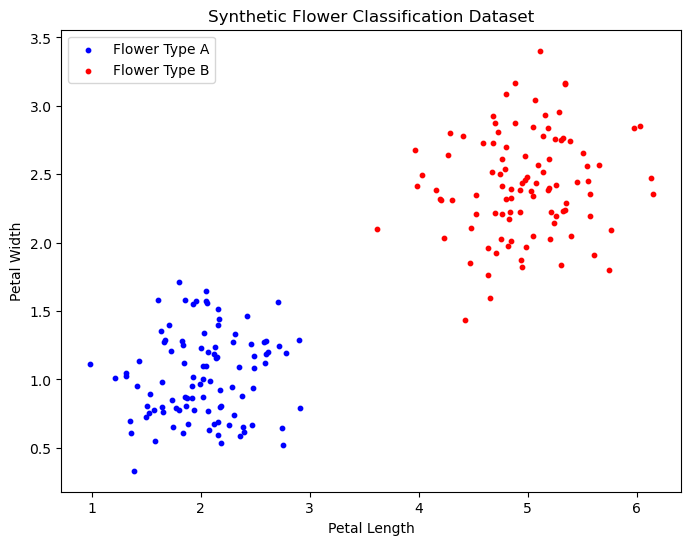

In [1]:
# Implementation using PyTorch
# Binary Classification Example: Flower Type Classification

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# Seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Generate data for Flower Type A
num_samples = 100

flower_A_petal_length = np.random.normal(2.0, 0.4, num_samples)
flower_A_petal_width = np.random.normal(1.0, 0.3, num_samples)
flower_A = np.column_stack((flower_A_petal_length, flower_A_petal_width))
labels_A = np.zeros(num_samples)

# Generate data for Flower Type B
flower_B_petal_length = np.random.normal(5.0, 0.5, num_samples)
flower_B_petal_width = np.random.normal(2.5, 0.4, num_samples)
flower_B = np.column_stack((flower_B_petal_length, flower_B_petal_width))
labels_B = np.ones(num_samples)

# Combine the two flower datasets
data = np.vstack((flower_A, flower_B)).astype(np.float32)
labels = np.hstack((labels_A, labels_B)).astype(np.float32).reshape(-1, 1)

# Shuffle the dataset
shuffle_index = np.random.permutation(len(data))
data = data[shuffle_index]
labels = labels[shuffle_index]

# Convert NumPy arrays to PyTorch tensors
x_train = torch.from_numpy(data)
y_train = torch.from_numpy(labels)

# Visualize the original dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    flower_A_petal_length,
    flower_A_petal_width,
    color="blue",
    s=10,
    label="Flower Type A"
)

plt.scatter(
    flower_B_petal_length,
    flower_B_petal_width,
    color="red",
    s=10,
    label="Flower Type B"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Synthetic Flower Classification Dataset")
plt.legend()
plt.show()


Sequential(
  (0): Linear(in_features=2, out_features=6, bias=True)
  (1): ReLU()
  (2): Linear(in_features=6, out_features=1, bias=True)
  (3): Sigmoid()
)
Epoch 100/1000, Loss: 0.5941
Epoch 200/1000, Loss: 0.5581
Epoch 300/1000, Loss: 0.5233
Epoch 400/1000, Loss: 0.4884
Epoch 500/1000, Loss: 0.4532
Epoch 600/1000, Loss: 0.4179
Epoch 700/1000, Loss: 0.3829
Epoch 800/1000, Loss: 0.3486
Epoch 900/1000, Loss: 0.3153
Epoch 1000/1000, Loss: 0.2836


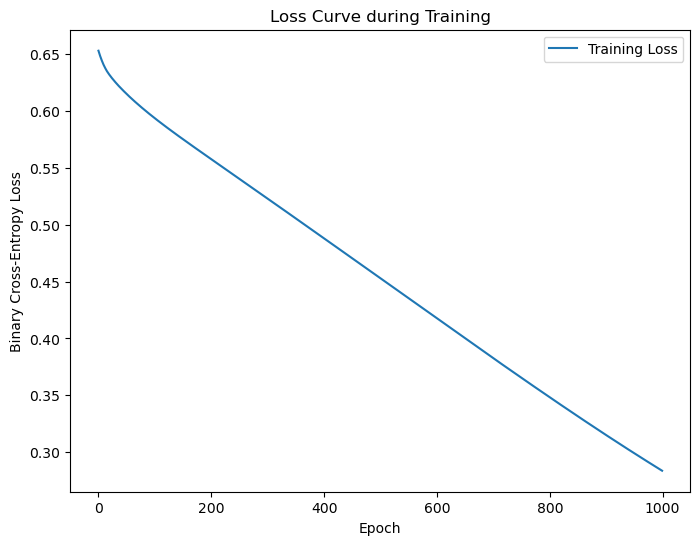

In [2]:
# Define the PyTorch ANN model
model = nn.Sequential(
    nn.Linear(2, 6),      # Input layer: 2 features -> 6 hidden neurons
    nn.ReLU(),            # ReLU activation
    nn.Linear(6, 1),      # Output layer: 6 hidden neurons -> 1 output
    nn.Sigmoid()          # Sigmoid activation for binary classification
)

print(model)

# Define binary cross-entropy loss
criterion = nn.BCELoss()

# Define the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training settings
epochs = 1000
losses = []

# Training loop
for epoch in range(epochs):

    # Forward pass
    y_pred = model(x_train)

    # Compute binary classification loss
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())

    # Backward pass and parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(np.arange(epochs), np.array(losses, dtype=np.float32), label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve during Training")
plt.legend()
plt.show()



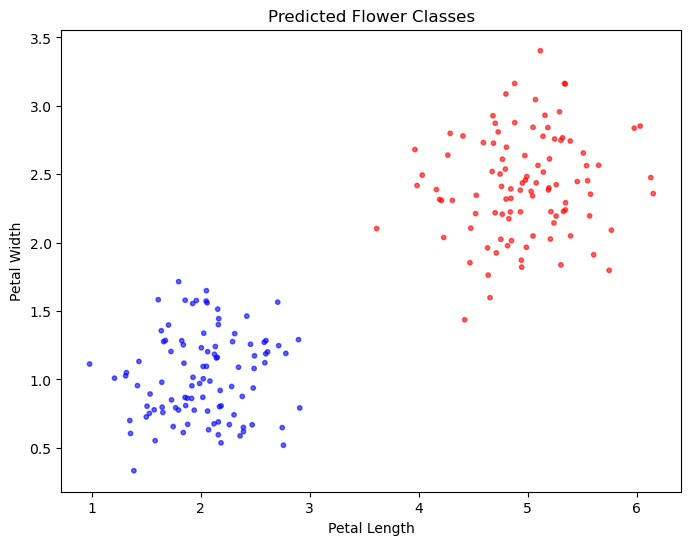

Final Accuracy: 100.00%


In [3]:
# Generate model predictions
with torch.no_grad():
    predictions = model(x_train)
    predicted_labels = (predictions >= 0.5).float()

# Visualize classification results
plt.figure(figsize=(8, 6))
plt.scatter(
    data[:, 0],
    data[:, 1],
    c=predicted_labels.view(-1).numpy(),
    cmap="bwr",
    s=10,
    alpha=0.6
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Predicted Flower Classes")
plt.show()

# Calculate final classification accuracy
accuracy = predicted_labels.eq(y_train).sum().item() / y_train.size(0)

print(f"Final Accuracy: {accuracy * 100:.2f}%")